# Credit Risk

### Instructor
 **Ashwani Kumar**: https://www.linkedin.com/in/ashwani-kumar-5322b02aa/


- Website: www.LoxfordAcademy.com
- Blog for this notebook: https://loxfordacademy.com/blog/deep-learn/artificial-neural-networks-for-credit-risk-analysis-a-deep-learning-approach-in-finance/
- Youtube: https://www.youtube.com/@Loxford-Academy/playlists
- mlflow experiment: https://youtu.be/WYHzW1TJwIA

# 🏦 Credit Risk Analysis using Artificial Neural Networks (ANN)

## Introduction

Credit risk assessment is one of the most critical applications of machine learning in the **finance domain**. Banks and financial institutions must predict whether a loan applicant is likely to default ("bad" risk) or repay ("good" risk) before approving credit.

### Why ANN for Credit Risk?
Artificial Neural Networks (ANNs) are powerful tools for this task because:
- They can learn **non-linear relationships** between features
- They handle **mixed data types** (numeric + categorical)
- They generalize well with sufficient data and regularization
- They are the foundation of **Deep Learning**, enabling scalable, production-grade models

### Dataset: German Credit Risk
The dataset contains **1000 loan applicants** with features such as:
- **Demographics**: Age, Sex
- **Employment**: Job type
- **Financial status**: Saving accounts, Checking account, Credit amount, Duration
- **Loan purpose**: Car, Education, Business, etc.
- **Target**: Risk — `good` or `bad`

---
**Workflow:**
```
Data Loading → EDA → Preprocessing → ANN Model → Training → Evaluation → Insights
```

## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Scikit-learn for preprocessing and evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras for ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

print(f'TensorFlow version : {tf.__version__}')

import importlib.metadata
print(f"Keras version      : {importlib.metadata.version('keras')}")

print('Libraries loaded successfully')

TensorFlow version : 2.18.0
Keras version      : 3.8.0
Libraries loaded successfully


## 2. Load and Inspect the Dataset

In [2]:
# Load the German Credit Risk dataset
df = pd.read_csv('https://raw.githubusercontent.com/ash322ash422/data/refs/heads/main/data_german_credit.csv', index_col=0)

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')

df.head(10)

Dataset shape: (1000, 10)

Column names: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,35,male,3,rent,little,moderate,6948,36,car,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad


In [3]:
# Summary statistics
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

=== Missing Values ===
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

=== Target Distribution ===


In [5]:
print('\n=== Target Distribution ===')

print(df['Risk'].value_counts())
print(f"\nClass balance: {df['Risk'].value_counts(normalize=True).round(3).to_dict()}")


=== Target Distribution ===
Risk
good    700
bad     300
Name: count, dtype: int64

Class balance: {'good': 0.7, 'bad': 0.3}


In [8]:
# Descriptive statistics for numerical features

df.describe().round(2)

,Age,Job,Credit amount,Duration
count,1000.00,1000.00,1000.00,1000.00
mean,35.55,1.90,3271.26,20.90
std,11.38,0.65,2822.74,12.06
min,19.00,0.00,250.00,4.00
25%,27.00,2.00,1365.50,12.00
50%,33.00,2.00,2319.50,18.00
75%,42.00,2.00,3972.25,24.00
max,75.00,3.00,18424.00,72.00


## 3. Exploratory Data Analysis (EDA)

Before building the model, we visualize the dataset to understand:
- Distribution of each feature
- Relationship between features and credit risk
- Class imbalance

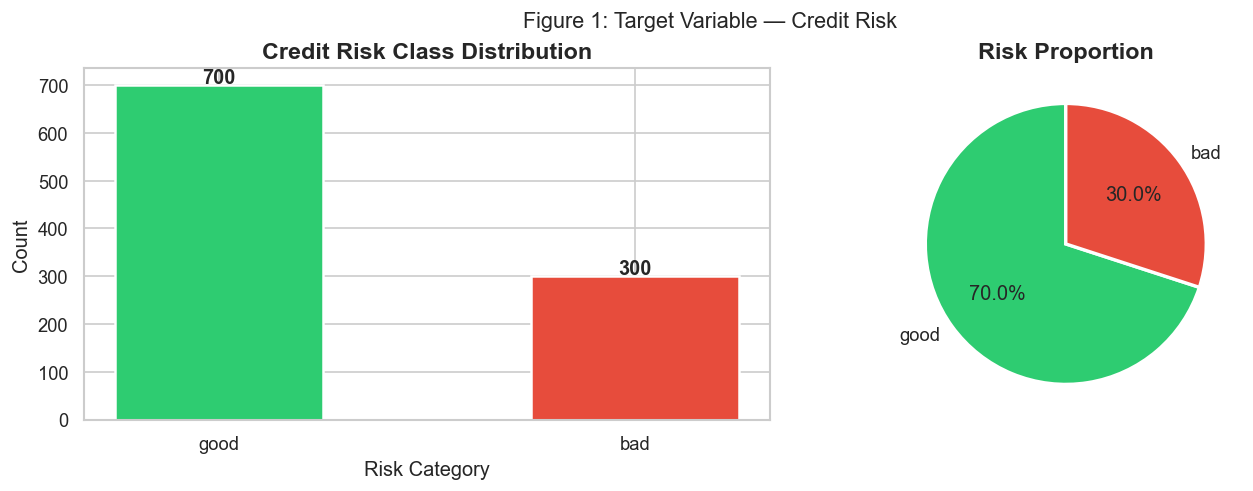

In [9]:
# ── 3.1  Target class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
counts = df['Risk'].value_counts()

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

axes[0].set_title('Credit Risk Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[1].set_title('Risk Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.suptitle('Figure 1: Target Variable — Credit Risk', y=1.02, fontsize=13)
plt.show()

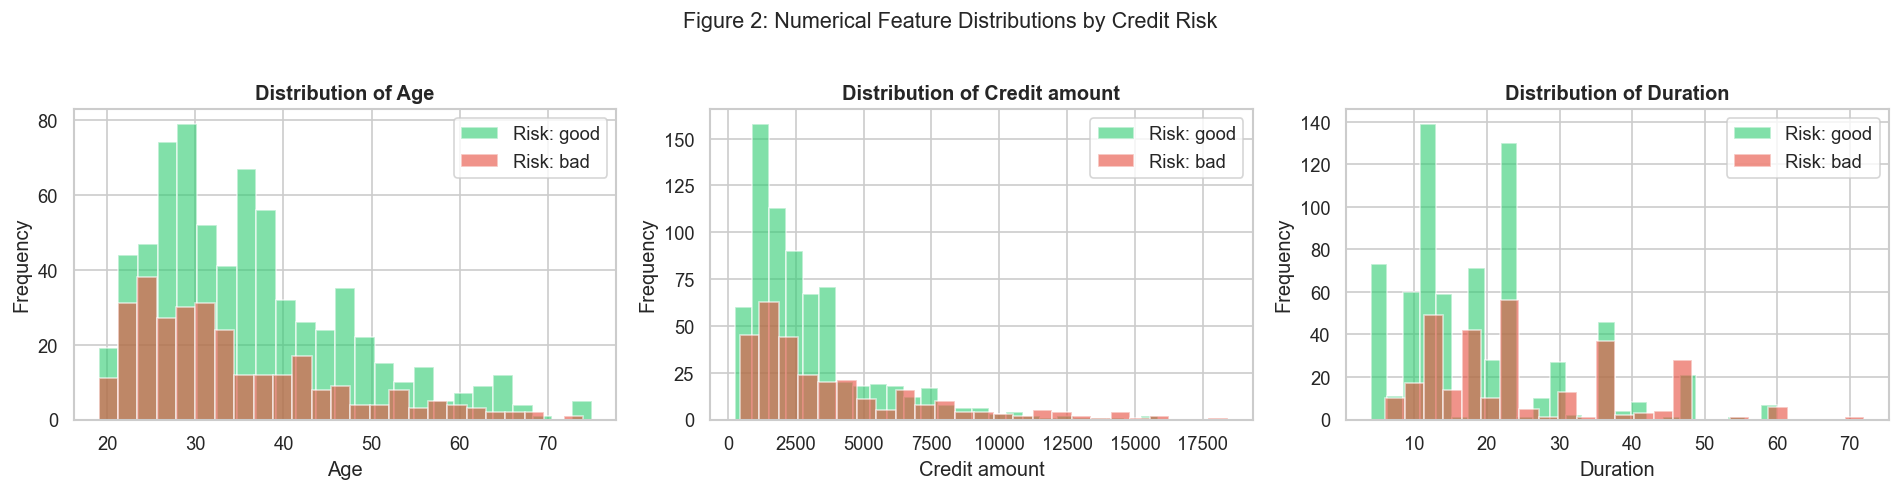

In [10]:
# 3.2  Numerical feature distributions by Risk 
num_features = ['Age', 'Credit amount', 'Duration']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, num_features):
    for risk, color in zip(['good', 'bad'], ['#2ecc71', '#e74c3c']):
        subset = df[df['Risk'] == risk][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=f'Risk: {risk}', edgecolor='white')
    ax.set_title(f'Distribution of {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Figure 2: Numerical Feature Distributions by Credit Risk', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Risk           bad       good
Housing                      
free     40.740741  59.259259
own      26.086957  73.913043
rent     39.106145  60.893855


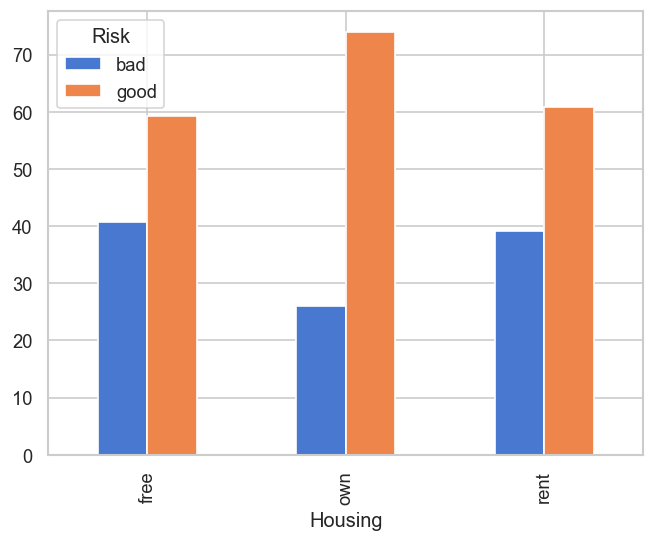

In [7]:
ct = pd.crosstab(df["Housing"], df['Risk'], normalize='index') * 100
print(ct)

ct.plot(kind='bar')
plt.show()

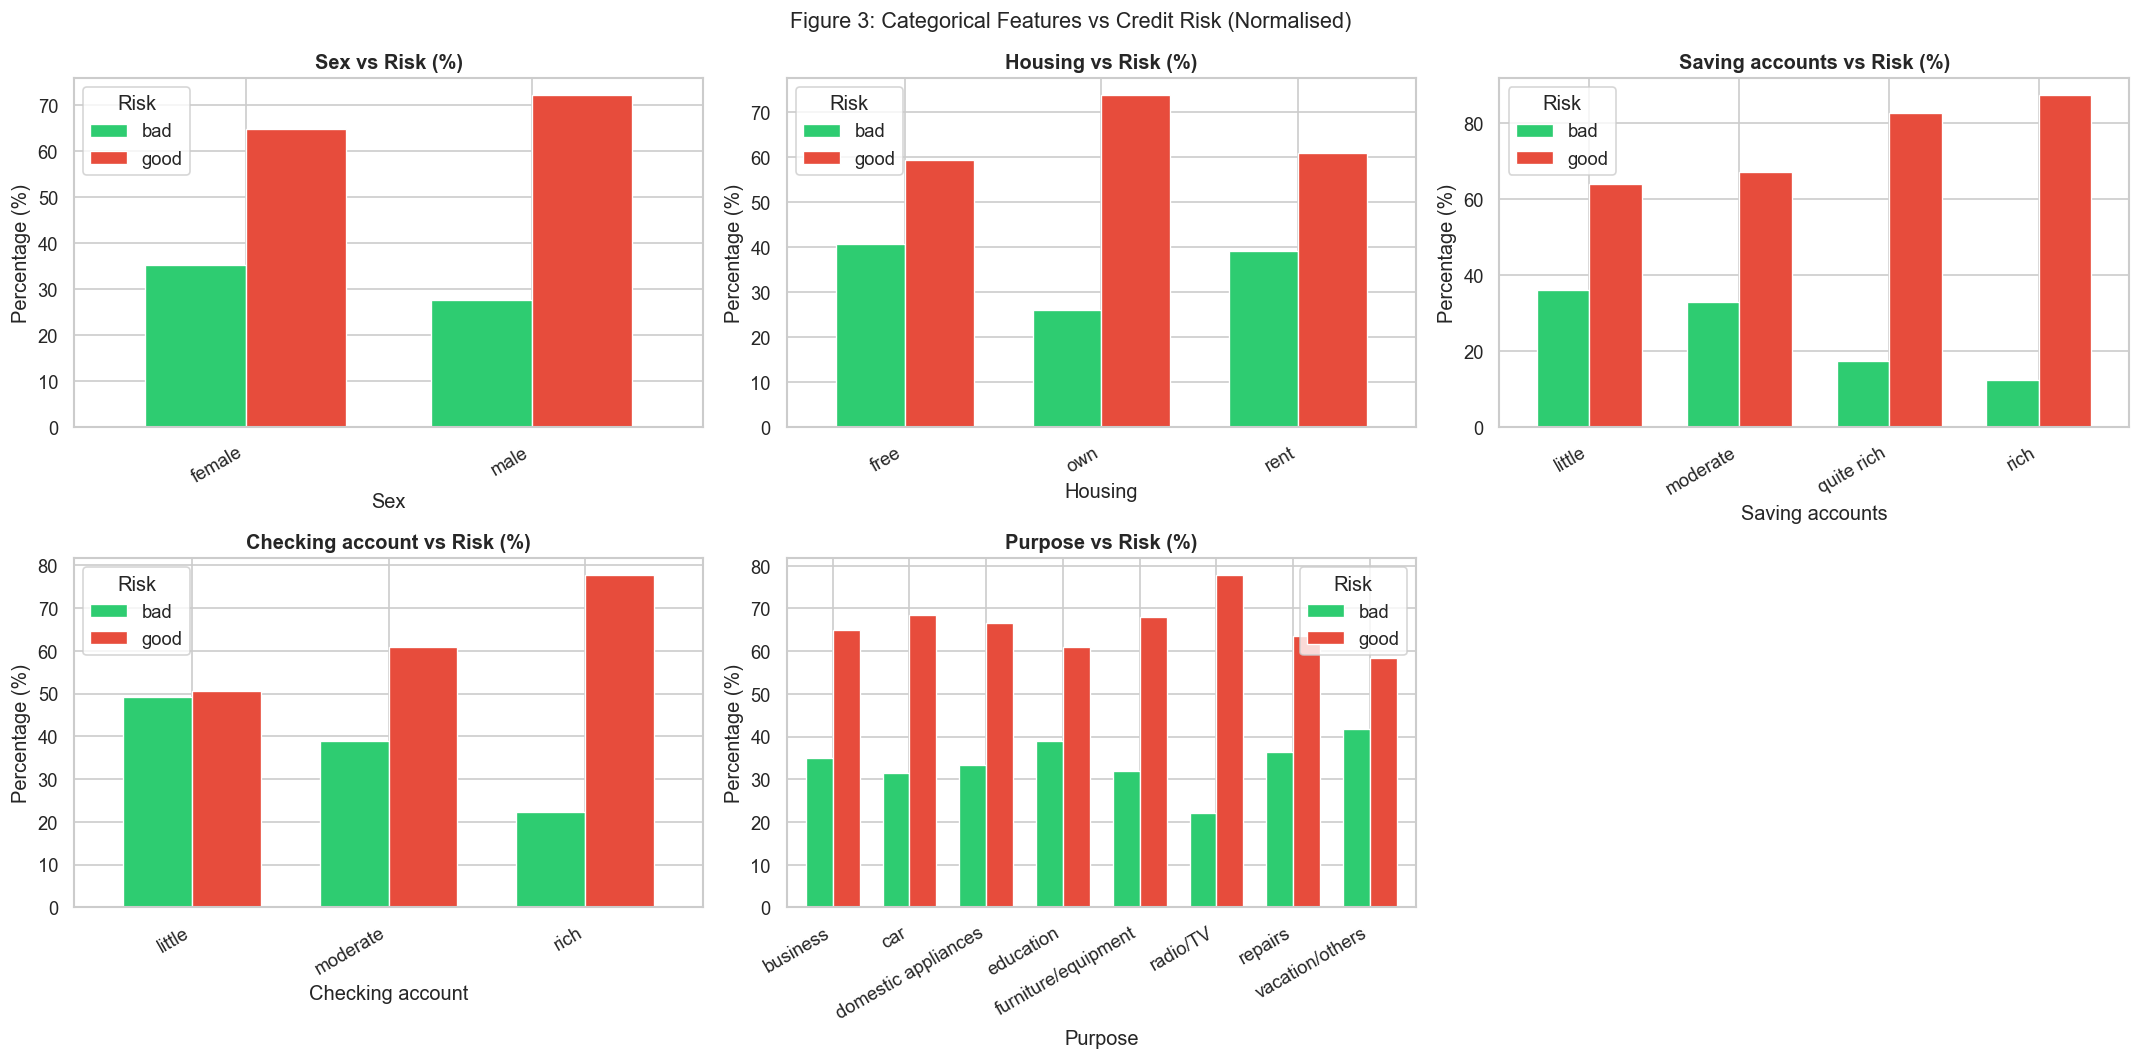

In [11]:
# 3.3  Categorical features vs Risk 
cat_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, feat in zip(axes, cat_features):
    ct = pd.crosstab(df[feat], df['Risk'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.8, width=0.7)
    
    ax.set_title(f'{feat} vs Risk (%)', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Risk')

# Remove unused subplot
axes[-1].set_visible(False)
plt.suptitle('Figure 3: Categorical Features vs Credit Risk (Normalised)', fontsize=13)
plt.tight_layout()
plt.show()

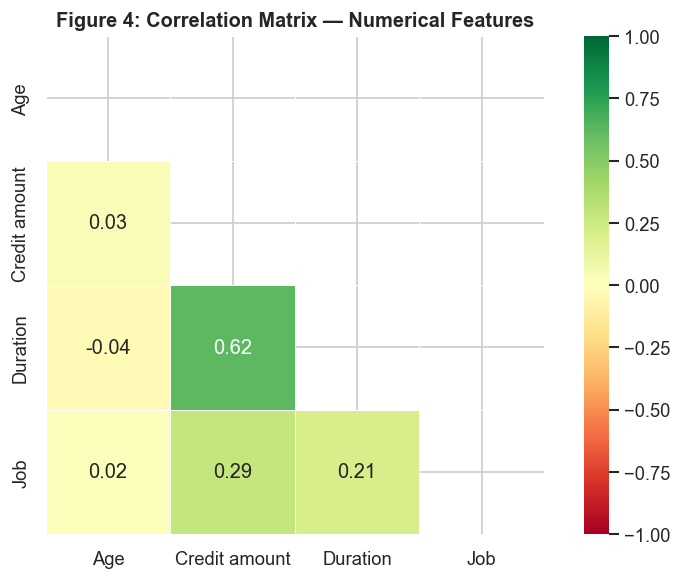


Key observation: Credit amount and Duration show moderate positive correlation.
This makes intuitive sense — larger loans typically have longer repayment periods.


In [8]:
#  3.4  Correlation heatmap (numerical only)
fig, ax = plt.subplots(figsize=(7, 5))
num_df = df[['Age', 'Credit amount', 'Duration', 'Job']].copy()
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, square=True)
ax.set_title('Figure 4: Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey observation: Credit amount and Duration show moderate positive correlation.')
print('This makes intuitive sense — larger loans typically have longer repayment periods.')

## 4. Data Preprocessing

ANNs require:
1. **No missing values** — impute or encode NaNs
2. **All-numeric input** — encode categorical variables
3. **Scaled features** — standardize to prevent large-valued features dominating gradients
4. **Numeric labels** — encode the target

In [9]:
# 4.1  Handle missing values
# 'NA' strings in Saving accounts and Checking account mean "no account"
# Treat them as a separate category: 'none'

df_proc = df.copy()
df_proc['Saving accounts'] = df_proc['Saving accounts'].fillna('none')
df_proc['Checking account'] = df_proc['Checking account'].fillna('none')

print('Missing values after imputation:')
print(df_proc.isnull().sum())

Missing values after imputation:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [13]:
# ── 4.2  Encode categorical features (One-Hot Encoding)
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

df_encoded = pd.get_dummies(df_proc, columns=cat_cols, drop_first=False)

# ── 4.3  Encode target variable 
# good → 1  (positive class: no default)
# bad  → 0  (negative class: default)
df_encoded['Risk'] = (df_encoded['Risk'] == 'good').astype(int)

print(f'Shape after encoding: {df_encoded.shape}')
print(f'\nFeature columns ({len(df_encoded.columns)-1}):')
features = [c for c in df_encoded.columns if c != 'Risk']
print(features)

Shape after encoding: (1000, 27)

Feature columns (26):
['Age', 'Job', 'Credit amount', 'Duration', 'Sex_female', 'Sex_male', 'Housing_free', 'Housing_own', 'Housing_rent', 'Saving accounts_little', 'Saving accounts_moderate', 'Saving accounts_none', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_little', 'Checking account_moderate', 'Checking account_none', 'Checking account_rich', 'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']


In [15]:
df_encoded.sample(3)

,Age,Job,Credit amount,Duration,Risk,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,...,Checking account_none,Checking account_rich,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
555,22,2,1331,12,0,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
395,32,2,11760,39,1,False,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
527,42,1,1503,4,1,False,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False


In [16]:
# ── 4.4  Split features and target
X = df_encoded.drop('Risk', axis=1).values.astype(np.float32)
y = df_encoded['Risk'].values.astype(np.float32)

# ── 4.5  Train / Validation / Test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# ── 4.6  Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # Fit ONLY on training data
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Training set   : {X_train.shape}  | Labels: {y_train.shape}')
print(f'Validation set : {X_val.shape}   | Labels: {y_val.shape}')
print(f'Test set       : {X_test.shape}   | Labels: {y_test.shape}')
print(f'\nTraining class balance — good: {y_train.sum():.0f}, bad: {(1-y_train).sum():.0f}')

Training set   : (700, 26)  | Labels: (700,)
Validation set : (150, 26)   | Labels: (150,)
Test set       : (150, 26)   | Labels: (150,)

Training class balance — good: 490, bad: 210


In [17]:
# ── 4.7  Handle class imbalance with class weights
# If good:bad = 70:30, the model may bias toward predicting 'good'
# Class weights penalize misclassification of the minority class more

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f'Class weights: {class_weight_dict}')
print('(Higher weight on class 0 = bad risk, penalises false negatives more)')

Class weights: {0: 1.6666666666666667, 1: 0.7142857142857143}
(Higher weight on class 0 = bad risk, penalises false negatives more)


## 5. Build the Artificial Neural Network (ANN)

### Architecture Design

We design a **feedforward ANN** (Multi-Layer Perceptron) with:

| Layer | Type | Units | Activation | Notes |
|-------|------|-------|------------|-------|
| Input | Dense | 64 | ReLU | Match input features |
| — | BatchNorm + Dropout(0.3) | — | — | Regularisation |
| Hidden 1 | Dense | 32 | ReLU | |
| — | BatchNorm + Dropout(0.2) | — | — | Regularisation |
| Hidden 2 | Dense | 16 | ReLU | |
| Output | Dense | 1 | Sigmoid | Binary classification |

> **Sigmoid** in the output layer maps values to [0, 1] — interpreted as the probability of **good** credit risk.

In [19]:
X_train

array([[-0.39189485,  0.13049425,  0.44059968, ...,  1.6092681 ,
        -0.15776625, -0.10752066],
       [ 0.9432433 ,  0.13049425, -0.5012435 , ...,  1.6092681 ,
        -0.15776625, -0.10752066],
       [-0.74793166, -1.4177426 ,  1.4896648 , ...,  1.6092681 ,
        -0.15776625, -0.10752066],
       ...,
       [ 2.4564    , -1.4177426 , -0.56322557, ...,  1.6092681 ,
        -0.15776625, -0.10752066],
       [ 1.210271  , -1.4177426 , -0.40613297, ..., -0.62140054,
        -0.15776625, -0.10752066],
       [ 0.14216042,  0.13049425,  0.15669313, ..., -0.62140054,
        -0.15776625, -0.10752066]], dtype=float32)

In [18]:
X_train.shape[1]

26

In [17]:
def build_ann(input_dim, learning_rate=0.001):
    """Build and compile the ANN model."""
    model = Sequential([
        # Input layer
        Dense(64, input_dim=input_dim, activation='relu', name='Input_Layer'),
        BatchNormalization(name='BN_1'),
        Dropout(0.30, name='Dropout_1'),

        # Hidden layer 1
        Dense(32, activation='relu', name='Hidden_Layer_1'),
        BatchNormalization(name='BN_2'),
        Dropout(0.20, name='Dropout_2'),

        # Hidden layer 2
        Dense(16, activation='relu', name='Hidden_Layer_2'),

        # Output layer — sigmoid for binary classification
        Dense(1, activation='sigmoid', name='Output_Layer')
    ], name='ANN_CreditRisk')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',      # Standard loss for binary classification
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_ann(input_dim=X_train.shape[1])
model.summary()


Model: "ANN_CreditRisk"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (Dense)         (None, 64)                1728      
                                                                 
 BN_1 (BatchNormalization)   (None, 64)                256       
                                                                 
 Dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 Hidden_Layer_1 (Dense)      (None, 32)                2080      
                                                                 
 BN_2 (BatchNormalization)   (None, 32)                128       
                                                                 
 Dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 Hidden_Layer_2 (Dense)      (None, 16)            

## 6. Train the ANN

### Training Strategy
- **Early Stopping**: Halt training when validation loss stops improving (prevents overfitting)
- **ReduceLROnPlateau**: Reduce learning rate when a plateau is detected (finer convergence)
- **Class weights**: Address class imbalance

In [18]:
# ── Callbacks 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# ── Train 
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/150


22/22 [==============================] - 4s 32ms/step - loss: 0.7744 - accuracy: 0.6171 - auc: 0.5179 - precision: 0.7293 - recall: 0.7204 - val_loss: 0.6263 - val_accuracy: 0.6600 - val_auc: 0.5744 - val_precision: 0.7077 - val_recall: 0.8762 - lr: 0.0010
Epoch 2/150
22/22 [==============================] - 0s 6ms/step - loss: 0.6974 - accuracy: 0.6243 - auc: 0.6106 - precision: 0.7621 - recall: 0.6735 - val_loss: 0.6266 - val_accuracy: 0.6600 - val_auc: 0.6541 - val_precision: 0.7547 - val_recall: 0.7619 - lr: 0.0010
Epoch 3/150
22/22 [==============================] - 0s 7ms/step - loss: 0.6523 - accuracy: 0.6386 - auc: 0.6747 - precision: 0.8094 - recall: 0.6327 - val_loss: 0.6217 - val_accuracy: 0.6800 - val_auc: 0.7062 - val_precision: 0.8065 - val_recall: 0.7143 - lr: 0.0010
Epoch 4/150
22/22 [==============================] - 0s 7ms/step - loss: 0.6347 - accuracy: 0.6614 - auc: 0.7019 - precision: 0.8203 - recall: 0.6612 - val_loss: 0.6141 - val_accuracy: 0.6933 -

## 7. Training History Visualisation

Plotting loss and accuracy curves helps diagnose:
- **Underfitting**: Both curves are poor
- **Overfitting**: Training improves but validation worsens
- **Good fit**: Both curves converge

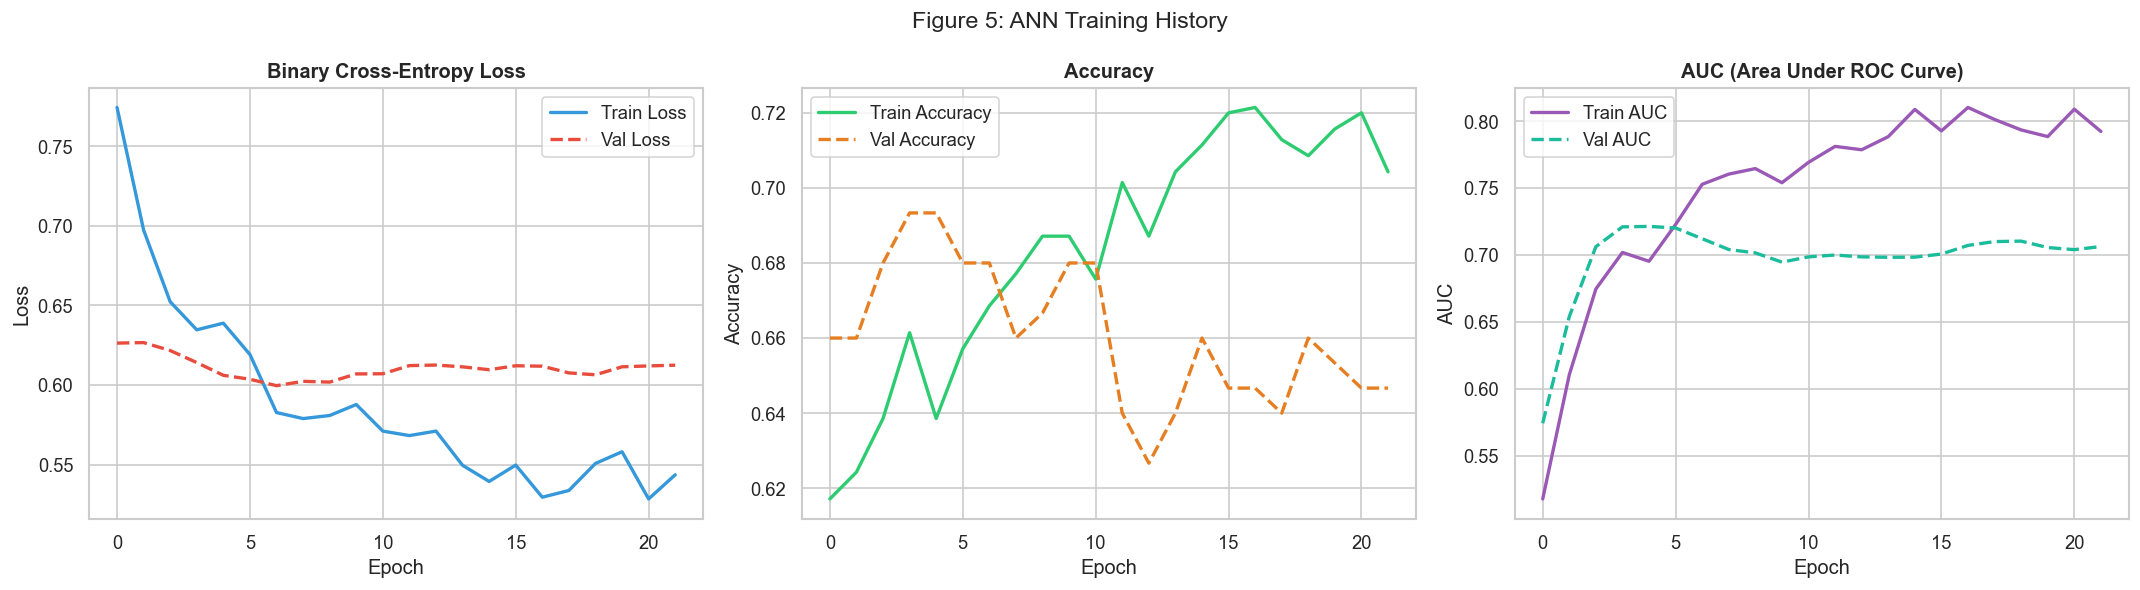

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db',
             linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c',
             linewidth=2, linestyle='--')

axes[0].set_title('Binary Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# AUC
axes[2].plot(history.history['auc'], label='Train AUC', color='#9b59b6', linewidth=2)
axes[2].plot(history.history['val_auc'], label='Val AUC', color='#1abc9c', linewidth=2, linestyle='--')
axes[2].set_title('AUC (Area Under ROC Curve)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('Figure 5: ANN Training History', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Model Evaluation on Test Set

We evaluate using multiple metrics because **accuracy alone is insufficient** for imbalanced credit datasets:

| Metric | Relevance |
|--------|-----------|
| **Accuracy** | Overall correctness |
| **Precision** | Of predicted "bad", how many were truly bad |
| **Recall** | Of all actual "bad", how many did we catch (critical for risk!) |
| **F1-Score** | Harmonic mean of Precision & Recall |
| **AUC-ROC** | Model's ability to discriminate between classes |

> ⚠️ In credit risk, **missing a bad debtor (False Negative) is more costly** than flagging a good applicant (False Positive). Hence, **Recall for the bad class is a priority metric**.

In [20]:
# ── Raw predictions 
y_prob = model.predict(X_test, verbose=0).flatten()   # Probability of class 1 (good)
y_pred = (y_prob >= 0.5).astype(int)

# ── Metrics 
acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 55)
print('          TEST SET PERFORMANCE SUMMARY')
print('=' * 55)
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  AUC-ROC    : {auc:.4f}')
print('=' * 55)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Bad Risk (0)', 'Good Risk (1)']))

          TEST SET PERFORMANCE SUMMARY
  Accuracy   : 0.6867  (68.7%)
  AUC-ROC    : 0.7407

Classification Report:
               precision    recall  f1-score   support

 Bad Risk (0)       0.48      0.69      0.57        45
Good Risk (1)       0.84      0.69      0.75       105

     accuracy                           0.69       150
    macro avg       0.66      0.69      0.66       150
 weighted avg       0.73      0.69      0.70       150



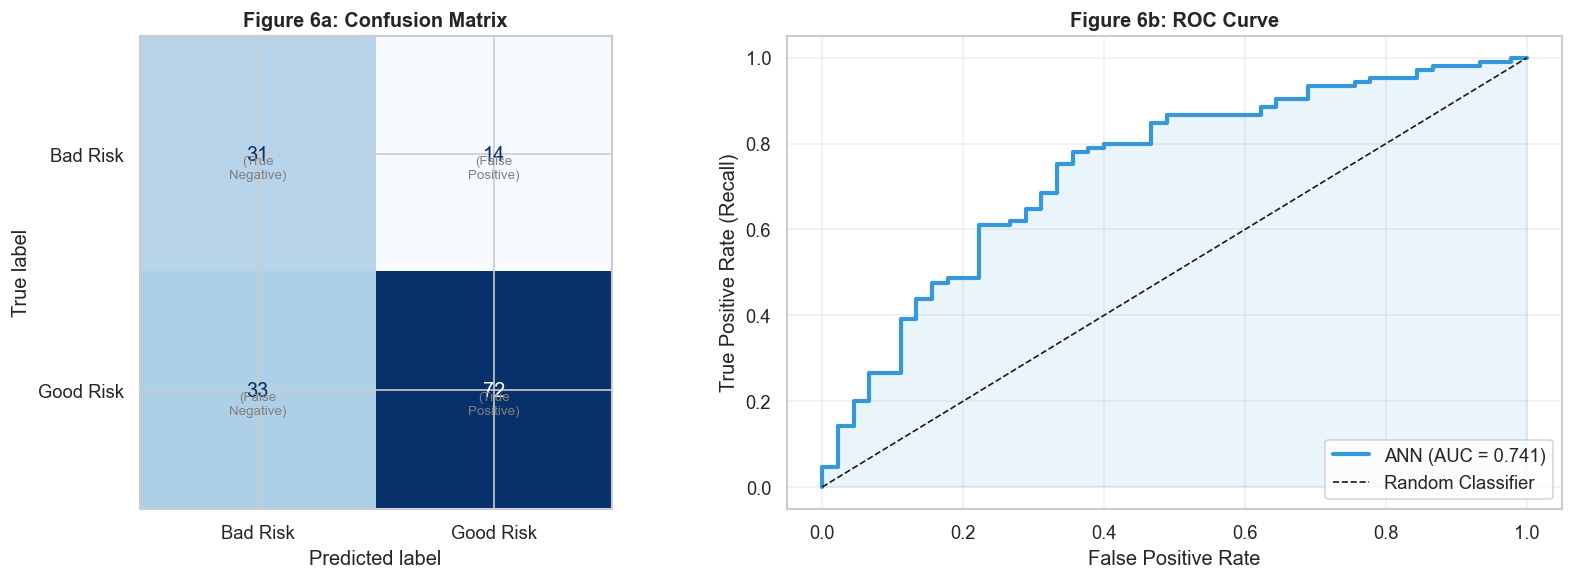

In [21]:
# ── 8.1  Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Bad Risk', 'Good Risk'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Figure 6a: Confusion Matrix', fontweight='bold')

# Annotate quadrants
labels = [['True\nNegative', 'False\nPositive'],
          ['False\nNegative', 'True\nPositive']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'\n\n({labels[i][j]})',
                     ha='center', va='center', fontsize=8, color='gray')

# ── 8.2  ROC Curve 
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2.5,
             label=f'ANN (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.10, color='#3498db')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Figure 6b: ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Interpreting the Model Results

### Overall Performance
The model achieves **68.7% accuracy** and an **AUC-ROC of 0.74**, which is a reasonable baseline for credit risk on a dataset of 1000 records. AUC of 0.74 means the model correctly ranks a randomly chosen good-risk applicant above a bad-risk one **74% of the time** — meaningfully better than random (0.50).

---

### Reading the Classification Report

#### Bad Risk (Class 0) — the minority class
| Metric | Value | Meaning |
|--------|-------|---------|
| Precision | 0.48 | Of everyone flagged as bad risk, only 48% actually were |
| Recall | 0.69 | The model caught 69% of all true bad debtors |
| F1-Score | 0.57 | Moderate — reflects the tension between precision and recall |

#### Good Risk (Class 1) — the majority class
| Metric | Value | Meaning |
|--------|-------|---------|
| Precision | 0.84 | Of everyone approved as good risk, 84% genuinely were |
| Recall | 0.69 | The model correctly identified 69% of all true good applicants |
| F1-Score | 0.75 | Solid performance on the dominant class |

---

### Why Is Bad Risk Precision Low (0.48)?

This is a direct consequence of **class imbalance** and **class weighting**. By assigning higher penalty to missing bad debtors, we trained the model to be aggressive in flagging risk — it would rather over-warn than miss a defaulter. The result:

- **More bad debtors caught** (Recall = 0.69) ✅
- **More false alarms** — good applicants incorrectly rejected (Precision = 0.48) ⚠️

This is the classic **Precision-Recall trade-off** and is entirely expected behaviour.

---

### Business Interpretation

From a banking perspective, the asymmetry in errors matters:

| Error Type | What Happened | Business Cost |
|------------|---------------|---------------|
| False Negative (missed bad debtor) | Approved a loan that defaults | **High** — financial loss |
| False Positive (rejected good customer) | Rejected a creditworthy applicant | **Medium** — lost revenue, customer dissatisfaction |

The model currently **prioritises avoiding false negatives**, which is typically the correct stance for a lender. A bank losing money on defaults is a worse outcome than occasionally turning away a good customer.

---

### Verdict

> A 0.74 AUC with 69% recall on bad risk is a **respectable result for a 1000-row dataset**. The model demonstrates that ANN can learn meaningful credit risk patterns from demographic and financial features alone. In a real deployment, this would serve as a first-pass screening layer, with borderline cases (predicted probability between 0.4–0.6) escalated to a human underwriter.

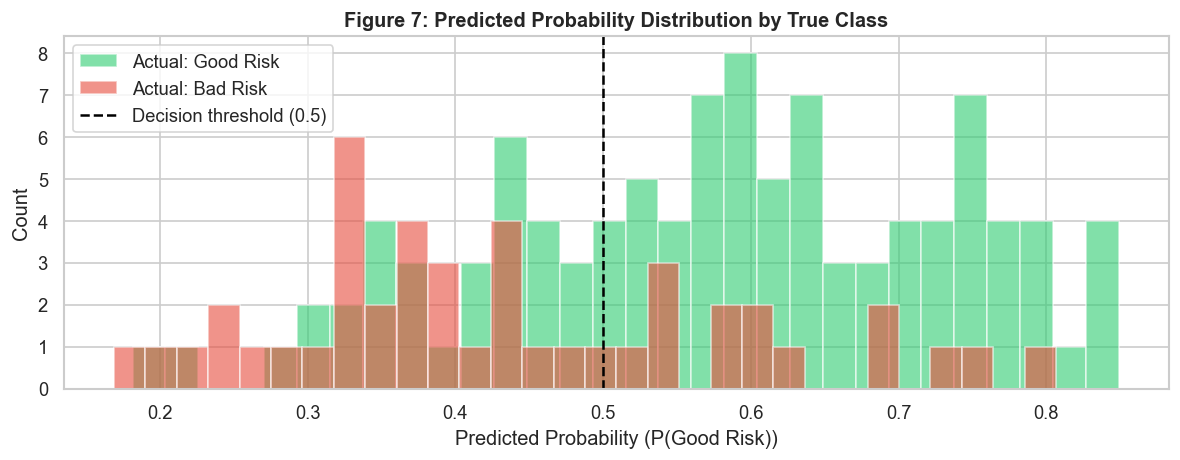

Ideal behaviour: green bars cluster near 1.0 and red bars near 0.0.
Overlap in the middle represents model uncertainty.


In [22]:
# ── 8.3  Prediction probability distribution 
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y_prob[y_test == 1], bins=30, alpha=0.6, color='#2ecc71',
        label='Actual: Good Risk', edgecolor='white')
ax.hist(y_prob[y_test == 0], bins=30, alpha=0.6, color='#e74c3c',
        label='Actual: Bad Risk', edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Probability (P(Good Risk))')
ax.set_ylabel('Count')
ax.set_title('Figure 7: Predicted Probability Distribution by True Class', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print('Ideal behaviour: green bars cluster near 1.0 and red bars near 0.0.')
print('Overlap in the middle represents model uncertainty.')

## 9. Feature Importance via Permutation

ANNs don't natively provide feature importance (unlike decision trees), but we can use **Permutation Importance**:
- Shuffle one feature at a time
- Measure how much accuracy drops
- Higher drop → more important feature

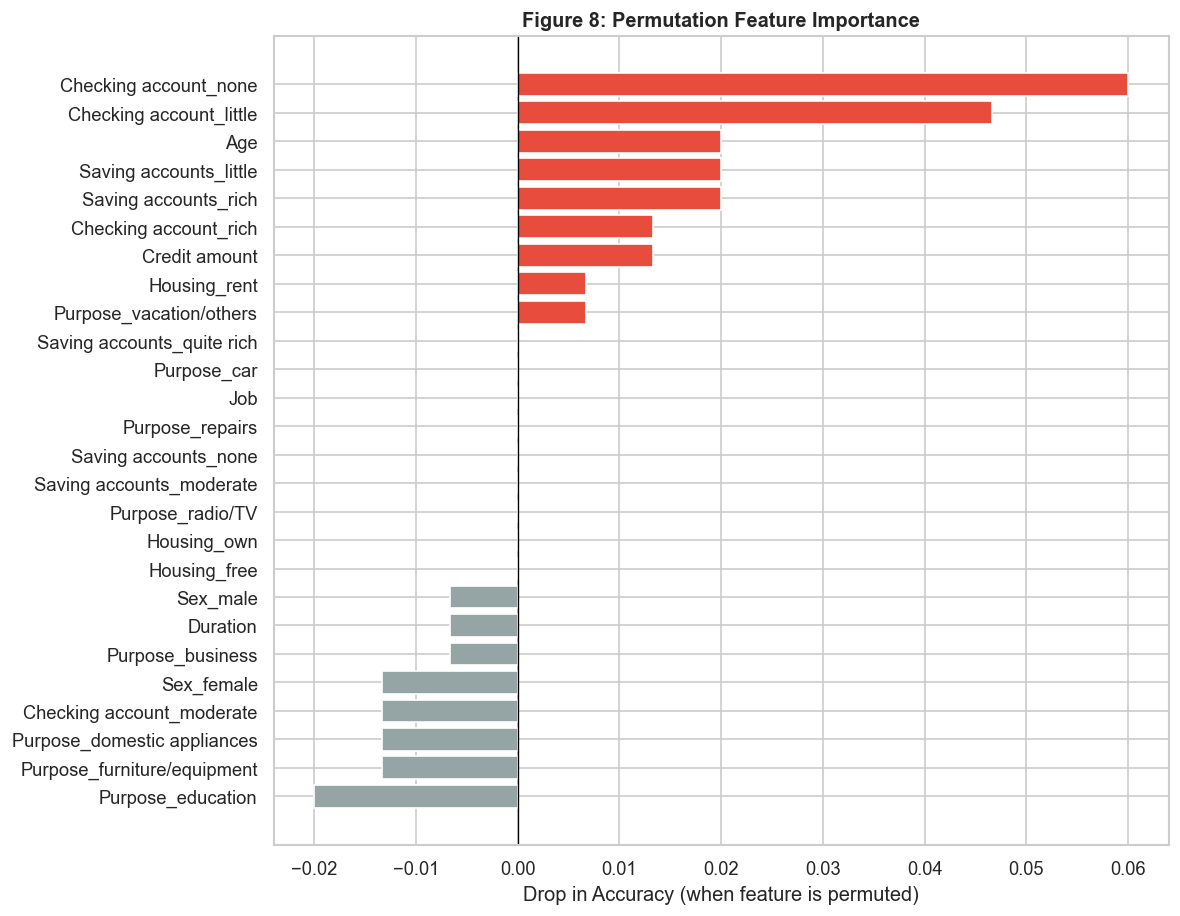


Top 5 most important features:
                    Feature  Importance
16    Checking account_none    0.060000
14  Checking account_little    0.046667
0                       Age    0.020000
9    Saving accounts_little    0.020000
13     Saving accounts_rich    0.020000


In [23]:
feature_names = [c for c in df_encoded.columns if c != 'Risk']

base_acc = accuracy_score(y_test, (model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int))
importances = []

for i in range(X_test.shape[1]):
    X_permuted = X_test.copy()
    np.random.shuffle(X_permuted[:, i])
    perm_prob = model.predict(X_permuted, verbose=0).flatten()
    perm_acc = accuracy_score(y_test, (perm_prob >= 0.5).astype(int))
    importances.append(base_acc - perm_acc)   # Drop in accuracy

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.3)))
colors_bar = ['#e74c3c' if v > 0 else '#95a5a6' for v in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Drop in Accuracy (when feature is permuted)')
ax.set_title('Figure 8: Permutation Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importance_df.sort_values('Importance', ascending=False).head())

## 10. Threshold Optimisation

The default decision threshold is **0.5**, but in credit risk:
- Lowering the threshold → model flags more applicants as "bad risk" → fewer defaults but more false rejections
- Raising the threshold → model approves more applicants → more defaults but fewer false rejections

We plot how Precision and Recall trade off at different thresholds.

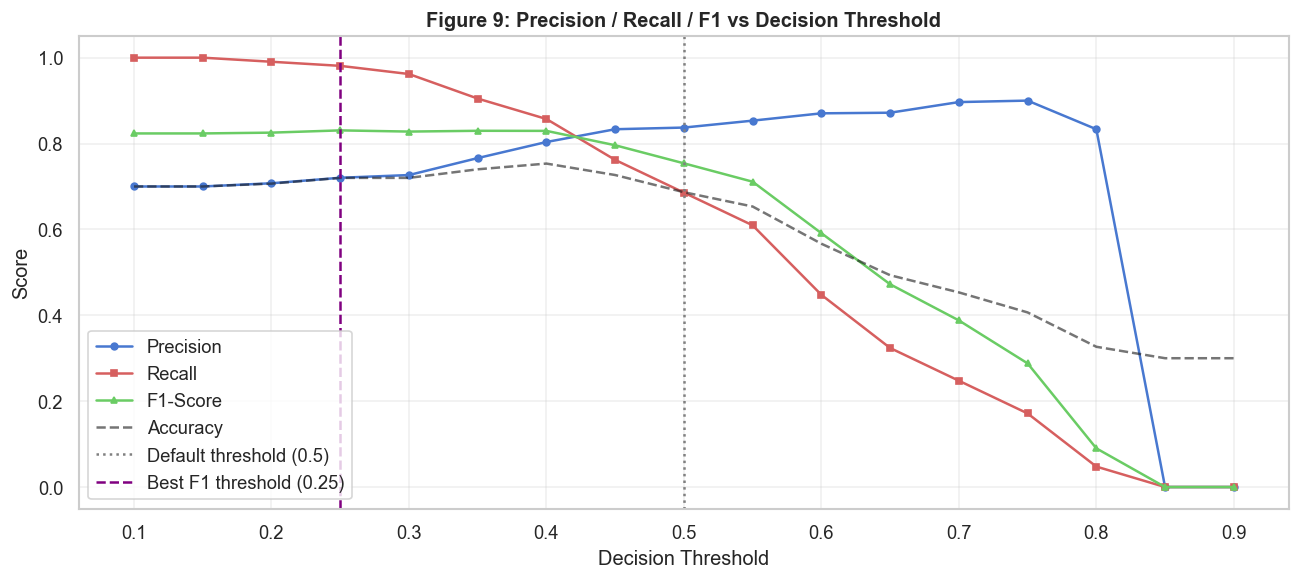

Best F1-score threshold : 0.25
F1 at best threshold    : 0.8306
Recall at best threshold: 0.9810


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_range = np.arange(0.1, 0.91, 0.05)
precisions, recalls, f1s, accs = [], [], [], []

for t in thresholds_range:
    y_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    accs.append(accuracy_score(y_test, y_t))

best_f1_idx = np.argmax(f1s)
best_threshold = thresholds_range[best_f1_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds_range, precisions, 'b-o', markersize=4, label='Precision')
ax.plot(thresholds_range, recalls, 'r-s', markersize=4, label='Recall')
ax.plot(thresholds_range, f1s, 'g-^', markersize=4, label='F1-Score')
ax.plot(thresholds_range, accs, 'k--', markersize=4, label='Accuracy', alpha=0.6)
ax.axvline(0.5, color='gray', linestyle=':', label='Default threshold (0.5)')
ax.axvline(best_threshold, color='purple', linestyle='--',
           label=f'Best F1 threshold ({best_threshold:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Figure 9: Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best F1-score threshold : {best_threshold:.2f}')
print(f'F1 at best threshold    : {f1s[best_f1_idx]:.4f}')
print(f'Recall at best threshold: {recalls[best_f1_idx]:.4f}')

## 11. Real-World Inference — Predict for New Applicants

We simulate how the trained model would evaluate a **new loan application** in a real banking scenario.

In [25]:
def predict_credit_risk(applicant_dict, model, scaler, feature_names):
    """
    Predict credit risk for a new applicant.
    
    Parameters
    ----------
    applicant_dict : dict  — raw applicant data (same format as training)
    model          : trained Keras model
    scaler         : fitted StandardScaler
    feature_names  : list of feature column names (post-encoding)
    
    Returns: probability and decision
    """
    df_new = pd.DataFrame([applicant_dict])
    df_new['Saving accounts']  = df_new['Saving accounts'].fillna('none')
    df_new['Checking account'] = df_new['Checking account'].fillna('none')
    df_new = pd.get_dummies(df_new)

    # Align columns
    for col in feature_names:
        if col not in df_new.columns:
            df_new[col] = 0
    df_new = df_new[feature_names]

    X_new = scaler.transform(df_new.values.astype(np.float32))
    prob  = model.predict(X_new, verbose=0)[0][0]
    label = 'GOOD RISK ✅' if prob >= 0.5 else 'BAD RISK ❌'
    return prob, label


# ── Example applicants ───────────────────────────────────────────────────
applicant_A = {
    'Age': 35, 'Sex': 'male', 'Job': 2, 'Housing': 'own',
    'Saving accounts': 'moderate', 'Checking account': 'moderate',
    'Credit amount': 3000, 'Duration': 12, 'Purpose': 'car'
}

applicant_B = {
    'Age': 22, 'Sex': 'female', 'Job': 1, 'Housing': 'rent',
    'Saving accounts': 'little', 'Checking account': 'little',
    'Credit amount': 9000, 'Duration': 60, 'Purpose': 'business'
}

for name, app in [('Applicant A', applicant_A), ('Applicant B', applicant_B)]:
    prob, decision = predict_credit_risk(app, model, scaler, feature_names)
    print(f'{name}: P(Good Risk) = {prob:.3f}  →  {decision}')

Applicant A: P(Good Risk) = 0.536  →  GOOD RISK ✅
Applicant B: P(Good Risk) = 0.317  →  BAD RISK ❌


## 12. Summary and Conclusions

### What We Did

| Step | Description |
|------|-------------|
| **EDA** | Explored class imbalance, feature distributions, correlations |
| **Preprocessing** | Imputed NaN account categories, one-hot encoded categoricals, standardized numerics |
| **ANN Architecture** | 3-layer feedforward network with BatchNorm & Dropout for regularisation |
| **Training** | Adam optimizer + EarlyStopping + LR scheduling + class weighting |
| **Evaluation** | Accuracy, AUC-ROC, Precision, Recall, F1, Confusion Matrix |
| **Explainability** | Permutation feature importance |
| **Deployment** | Threshold analysis + live inference function |

### Key Takeaways

1. **ANNs are well-suited** for tabular credit data — they capture non-linear patterns that simpler models miss.
2. **Class imbalance handling** is critical; without class weights, the model would simply predict "good" for everyone.
3. **Threshold tuning** allows the bank to control the trade-off between approving risky loans and rejecting good customers.
4. **Recall on bad risk** is the most business-critical metric — missing a defaulter is more expensive than rejecting a good applicant.
5. **Deep Learning** adds value here via automatic feature interactions — the network discovers that high credit amount + long duration + little savings is a risky combination, without being explicitly told.

### Business Impact

A well-calibrated ANN credit risk model enables banks to:
- **Reduce NPAs** (Non-Performing Assets) by identifying risky borrowers early
- **Automate loan screening** at scale, reducing manual underwriting effort
- **Maintain fairness** by using objective, data-driven criteria
- **Customise risk appetite** by tuning the decision threshold

In [ ]:
# ── Save the trained model ────────────────────────────────────────────────
model.save('ann_credit_risk_model.keras')
print('Model saved as ann_credit_risk_model.keras')
print('\n=== Final Test Set Results ===')
print(f'  Accuracy : {acc:.4f}')
print(f'  AUC-ROC  : {auc:.4f}')
print(f'\nNotebook complete ✅')